In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [2]:
# Load IMDB dataset (top 10,000 words)
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training samples: 25000
Testing samples: 25000


In [3]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print(X_train.shape)

(25000, 200)


In [4]:
model = Sequential()

model.add(Embedding(vocab_size, 128, input_length=max_len))
model.add(SimpleRNN(64))
model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)             │ ?                        │   0 (unbuilt) │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)            │ ?                        │   0 (unbuilt) │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ ?                        │   0 (unbuilt) │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.9995 - loss: 0.0062 - val_accuracy: 0.7296 - val_loss: 0.9576
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9999 - loss: 0.0024 - val_accuracy: 0.7694 - val_loss: 0.8693
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.9999 - loss: 0.0013 - val_accuracy: 0.7598 - val_loss: 0.9326
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.9999 - loss: 7.9193e-04 - val_accuracy: 0.7796 - val_loss: 0.9057
Epoch 5/5
123/313 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 1.0000 - loss: 6.0816e-04

In [6]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7624 - loss: 0.7731
Test Accuracy: 0.7623599767684937


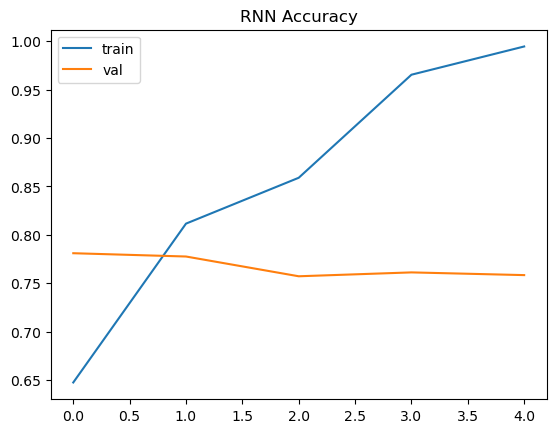

In [7]:
plt.plot(history.history['accuracy'], label="train")
plt.plot(history.history['val_accuracy'], label="val")
plt.legend()
plt.title("RNN Accuracy")
plt.show()

In [8]:
sample = X_test[0:1]
prediction = model.predict(sample)

print("Prediction:", prediction)
print("Class:", "Positive" if prediction > 0.5 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Prediction: [[0.43088803]]
Class: Negative
